<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/911.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df=pd.read_csv('911.csv')
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,10-12-2015 17:40,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,10-12-2015 17:40,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,10-12-2015 17:40,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,10-12-2015 17:40,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,10-12-2015 17:40,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [ ]:
df.shape

(99492, 9)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


In [ ]:
df.columns

Index(['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e'], dtype='object')

In [ ]:
df['zip'].value_counts().head(5)

,count
zip,
19401.0,6979
19464.0,6643
19403.0,4854
19446.0,4748
19406.0,3174


In [ ]:
df['twp'].value_counts().head(5)

,count
twp,
LOWER MERION,8443
ABINGTON,5977
NORRISTOWN,5890
UPPER MERION,5227
CHELTENHAM,4575


In [ ]:
df['title'].unique()
print (len(df['title'].unique()))

110


In [ ]:
x=df['title'].iloc[0]

In [ ]:
x.split(':')[0]

'EMS'

In [ ]:
df['Reason']=df['title'].apply(lambda title:title.split(':')[0])

In [ ]:
df['Reason'].unique()

array(['EMS', 'Fire', 'Traffic'], dtype=object)

In [ ]:
df['Reason'].value_counts()

,count
Reason,
EMS,48877
Traffic,35695
Fire,14920


/tmp/ipython-input-2424239774.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Reason',data=df,palette='viridis')


<Axes: xlabel='Reason', ylabel='count'>

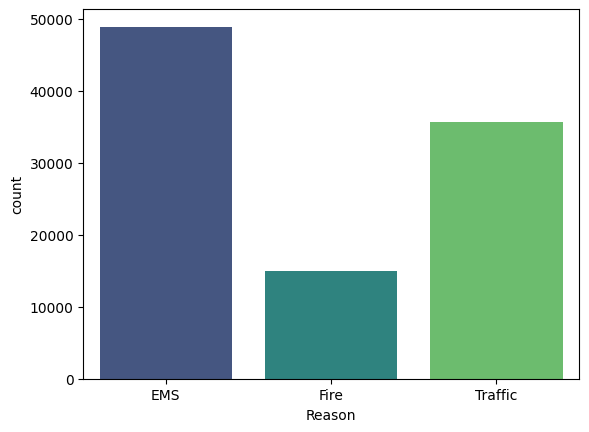

In [ ]:
sns.countplot(x='Reason',data=df,palette='viridis')

In [ ]:
type(df['timeStamp'].iloc[0])

str

In [ ]:
df['timeStamp']=pd.to_datetime(df['timeStamp'].iloc[0])

In [ ]:
type(df['timeStamp'].iloc[0])

pandas._libs.tslibs.timestamps.Timestamp

In [ ]:
time=df['timeStamp'].iloc[0]
time.dayofweek

0

In [ ]:
time.hour

17

In [ ]:
df['hour']=df['timeStamp'].apply(lambda time:time.hour)
df['month']=df['timeStamp'].apply(lambda time:time.month)
df['day of week']=df['timeStamp'].apply(lambda time:time.dayofweek)

In [ ]:
df.head(3)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,hour,month,day of week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-10-12 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,10,0
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-10-12 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,10,0
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-10-12 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,17,10,0


In [ ]:
dmap={0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'sun'}

In [ ]:
df['day of week']=df['day of week'].map(dmap)

In [ ]:
df['day of week'].unique()

array(['Mon'], dtype=object)

<Axes: xlabel='day of week', ylabel='count'>

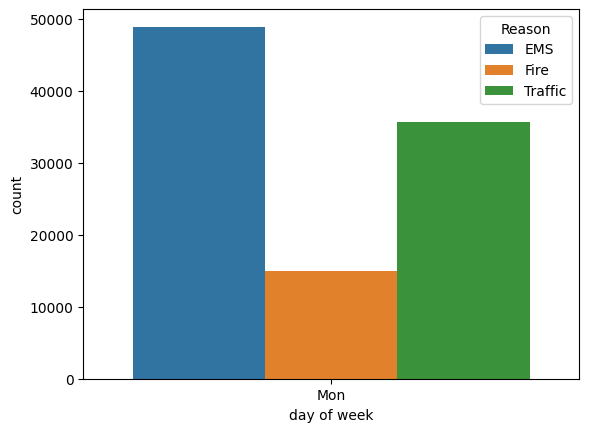

In [ ]:
sns.countplot(x='day of week',hue='Reason',data=df)

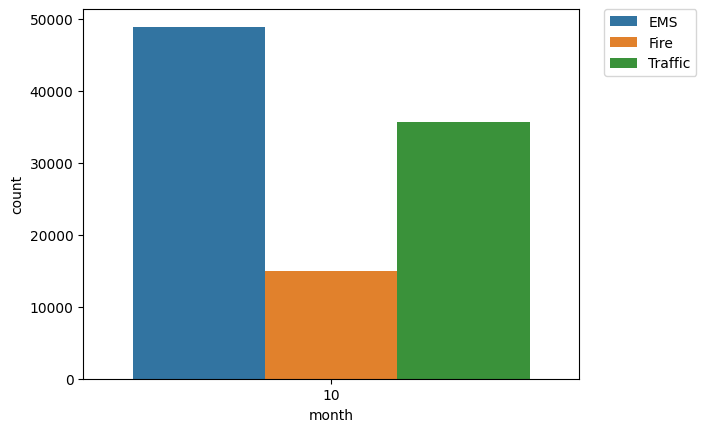

In [ ]:
sns.countplot(x='month',data=df,hue='Reason')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2,borderaxespad=0.)

In [ ]:
bymonth=df.groupby('month').count()
bymonth.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,hour,day of week
month,,,,,,,,,,,,
10,99492,99492,99492,86637,99492,99492,99449,98973,99492,99492,99492,99492


<Axes: xlabel='month'>

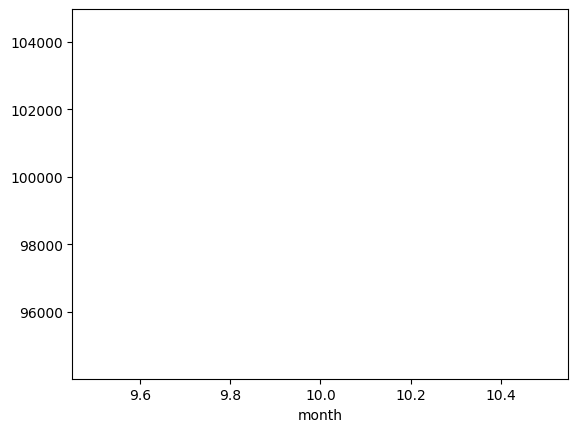

In [ ]:
bymonth['lat'].plot()

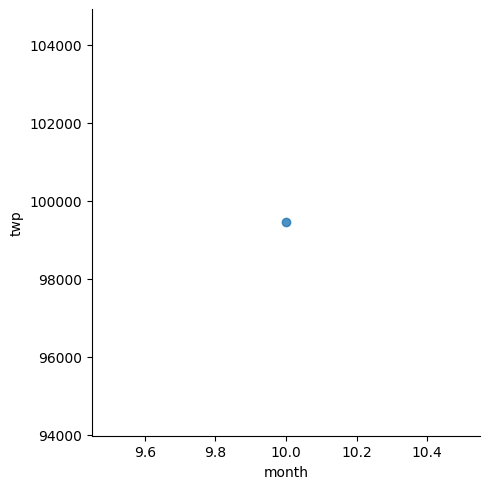

In [ ]:
sns.lmplot(x='month',y='twp',data=bymonth.reset_index())

In [ ]:
bymonth.reset_index()

,month,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,hour,day of week
0,10,99492,99492,99492,86637,99492,99492,99449,98973,99492,99492,99492,99492


In [ ]:
df['date']=df['timeStamp'].apply(lambda t:t.date())

In [ ]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,hour,month,day of week,date
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-10-12 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,10,Mon,2015-10-12
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-10-12 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,10,Mon,2015-10-12
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-10-12 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,17,10,Mon,2015-10-12
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-10-12 17:40:00,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,17,10,Mon,2015-10-12
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-10-12 17:40:00,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,17,10,Mon,2015-10-12


In [ ]:
df.groupby("date").count().head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,hour,month,day of week
date,,,,,,,,,,,,,
2015-10-12,99492,99492,99492,86637,99492,99492,99449,98973,99492,99492,99492,99492,99492


In [ ]:
df.groupby('date').count()['lat']

,lat
date,
2015-10-12,99492


<Axes: xlabel='date'>

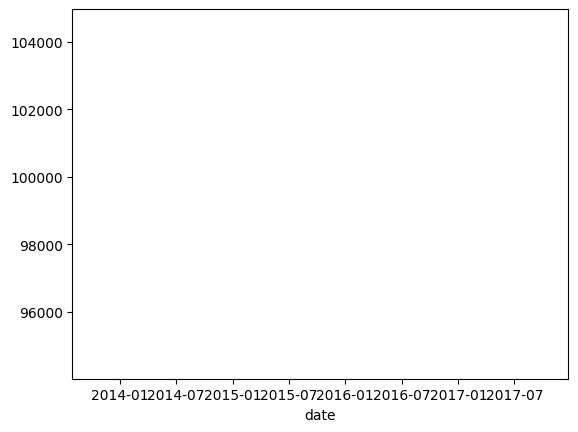

In [ ]:
df.groupby('date').count()['lat'].plot()

In [ ]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='date'>

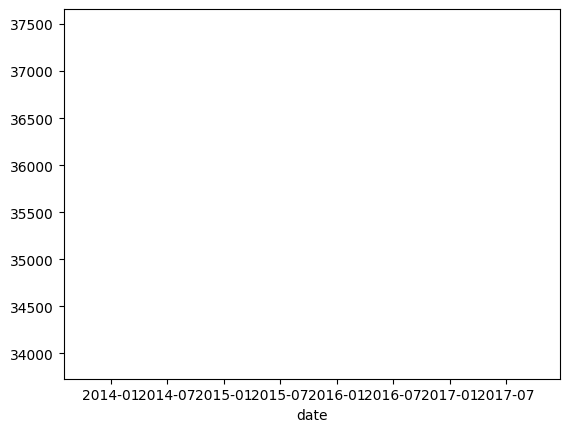

In [ ]:
df[df['Reason']=="Traffic"].groupby('date').count()['lat'].plot()

<Axes: xlabel='date'>

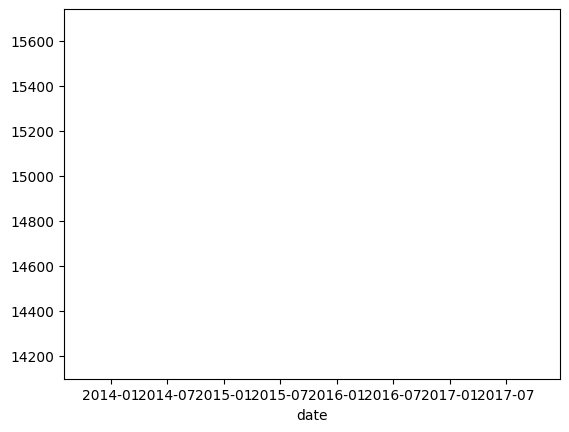

In [ ]:
df[df['Reason']=='Fire'].groupby('date').count()['lat'].plot()

<Axes: xlabel='date'>

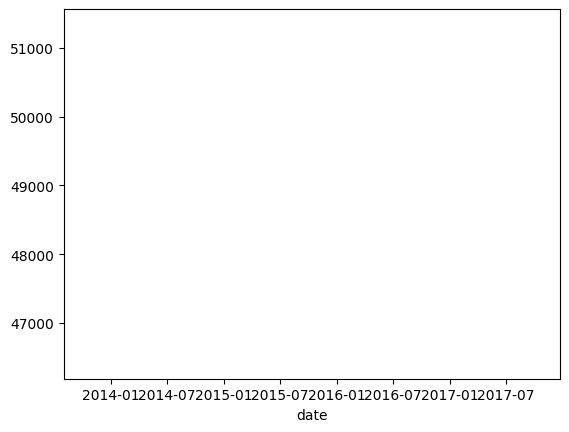

In [ ]:
df[df['Reason']=="EMS"].groupby('date').count()['lat'].plot()

In [ ]:
df.groupby(by=['day of week','hour']).count()['Reason'].unstack()

hour,17
day of week,
Mon,99492


In [ ]:
dayhour=df.groupby(by=['day of week','hour']).count()['Reason'].unstack()

<Axes: xlabel='hour', ylabel='day of week'>

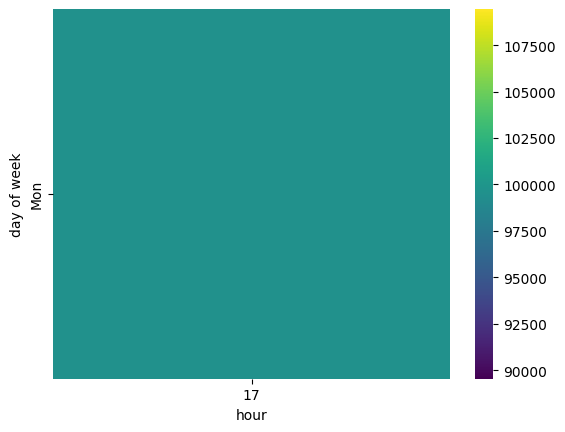

In [ ]:
sns.heatmap(dayhour,cmap='viridis')

ValueError: The number of observations cannot be determined on an empty distance matrix.

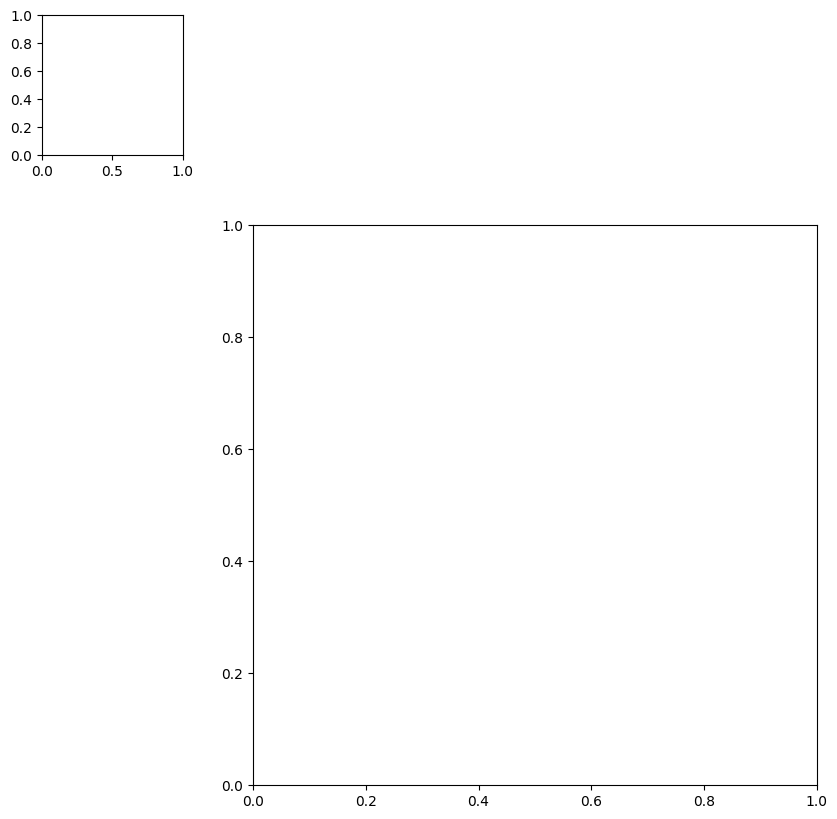

In [ ]:
sns.clustermap(dayhour)

In [ ]:
daymonth=df.groupby(by=['month','day of week']).count()['Reason'].unstack()

In [ ]:
daymonth.head()

day of week,Mon
month,
10,99492


<Axes: xlabel='day of week', ylabel='month'>

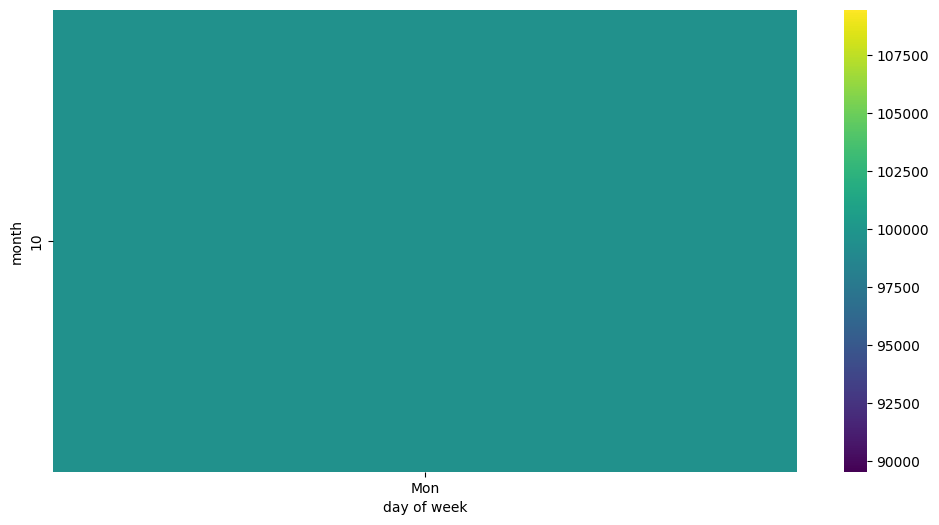

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(daymonth,cmap='viridis')

**Finance Data**

In [ ]:
from pandas_datareader import data, wb

In [ ]:
df=pd.read_pickle('all_banks')
df.head()

Bank Ticker    BAC                                     C                       \
Stock Info    Open   High    Low  Close    Volume   Open   High    Low  Close   
Date                                                                            
2006-01-03   46.92  47.18  46.15  47.08  16296700  490.0  493.8  481.1  492.9   
2006-01-04   47.00  47.24  46.45  46.58  17757900  488.6  491.0  483.5  483.8   
2006-01-05   46.58  46.83  46.32  46.64  14970900  484.4  487.8  484.0  486.2   
2006-01-06   46.80  46.91  46.35  46.57  12599800  488.8  489.0  482.0  486.2   
2006-01-09   46.72  46.97  46.36  46.60  15620000  486.0  487.4  483.0  483.9   

Bank Ticker           ...     MS                                  WFC         \
Stock Info    Volume  ...   Open   High    Low  Close   Volume   Open   High   
Date                  ...                                                      
2006-01-03   1537660  ...  57.17  58.49  56.74  58.31  5377000  31.60  31.98   
2006-01-04   1871020  ...  58.70  59.28  58.35  58.35  7977800  31.80  31.82   
2006-01-05   1143160  ...  58.55  58.59  58.02  58.51  5778000  31.50  31.56   
2006-01-06   1370250  ...  58.77  58.85  58.05  58.57  6889800  31.58  31.78   
2006-01-09   1680740  ...  58.63  59.29  58.62  59.19  4144500  31.68  31.82   

Bank Ticker                          
Stock Info     Low  Close    Volume  
Date                                 
2006-01-03   31.20  31.90  11016400  
2006-01-04   31.36  31.53  10871000  
2006-01-05   31.31  31.50  10158000  
2006-01-06   31.38  31.68   8403800  
2006-01-09   31.56  31.68   5619600  

[5 rows x 30 columns]

In [ ]:
df.shape

(2517, 30)

In [ ]:
df.columns

MultiIndex([('BAC',   'Open'),
            ('BAC',   'High'),
            ('BAC',    'Low'),
            ('BAC',  'Close'),
            ('BAC', 'Volume'),
            (  'C',   'Open'),
            (  'C',   'High'),
            (  'C',    'Low'),
            (  'C',  'Close'),
            (  'C', 'Volume'),
            ( 'GS',   'Open'),
            ( 'GS',   'High'),
            ( 'GS',    'Low'),
            ( 'GS',  'Close'),
            ( 'GS', 'Volume'),
            ('JPM',   'Open'),
            ('JPM',   'High'),
            ('JPM',    'Low'),
            ('JPM',  'Close'),
            ('JPM', 'Volume'),
            ( 'MS',   'Open'),
            ( 'MS',   'High'),
            ( 'MS',    'Low'),
            ( 'MS',  'Close'),
            ( 'MS', 'Volume'),
            ('WFC',   'Open'),
            ('WFC',   'High'),
            ('WFC',    'Low'),
            ('WFC',  'Close'),
            ('WFC', 'Volume')],
           names=['Bank Ticker', 'Stock Info'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2517 entries, 2006-01-03 to 2015-12-31
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (BAC, Open)    2517 non-null   float64
 1   (BAC, High)    2517 non-null   float64
 2   (BAC, Low)     2517 non-null   float64
 3   (BAC, Close)   2517 non-null   float64
 4   (BAC, Volume)  2517 non-null   int64  
 5   (C, Open)      2517 non-null   float64
 6   (C, High)      2517 non-null   float64
 7   (C, Low)       2517 non-null   float64
 8   (C, Close)     2517 non-null   float64
 9   (C, Volume)    2517 non-null   int64  
 10  (GS, Open)     2517 non-null   float64
 11  (GS, High)     2517 non-null   float64
 12  (GS, Low)      2517 non-null   float64
 13  (GS, Close)    2517 non-null   float64
 14  (GS, Volume)   2517 non-null   int64  
 15  (JPM, Open)    2517 non-null   float64
 16  (JPM, High)    2517 non-null   float64
 17  (JPM, Low)     2517 non-null   flo

In [ ]:
from datetime import datetime
start=datetime(2006,1,1)
end=datetime(2016,1,1)

In [ ]:
#bank of america
BAC=df['BAC']
BAC=BAC.loc[start:end]
BAC.head()

#citigroup
C=df['C']
C=C.loc[start:end]
C.head()

#goldman
GS=df['GS']
GS=GS.loc[start:end]
GS.head()

#jpmorgan
JPM=df['JPM']
JPM=JPM.loc[start:end]
JPM.head()

#morgan stanley
MS=df['MS']
MS=MS.loc[start:end]
MS.head()

#well fargo
WFC=df['WFC']
WFC=WFC.loc[start:end]




In [ ]:
BAC.head()

Stock Info,Open,High,Low,Close,Volume
Date,,,,,
2006-01-03,46.92,47.18,46.15,47.08,16296700
2006-01-04,47.00,47.24,46.45,46.58,17757900
2006-01-05,46.58,46.83,46.32,46.64,14970900
2006-01-06,46.80,46.91,46.35,46.57,12599800
2006-01-09,46.72,46.97,46.36,46.60,15620000


In [ ]:
C.head()

Stock Info,Open,High,Low,Close,Volume
Date,,,,,
2006-01-03,490.0,493.8,481.1,492.9,1537660
2006-01-04,488.6,491.0,483.5,483.8,1871020
2006-01-05,484.4,487.8,484.0,486.2,1143160
2006-01-06,488.8,489.0,482.0,486.2,1370250
2006-01-09,486.0,487.4,483.0,483.9,1680740


In [ ]:
GS.head()

Stock Info,Open,High,Low,Close,Volume
Date,,,,,
2006-01-03,126.70,129.44,124.23,128.87,6188700
2006-01-04,127.35,128.91,126.38,127.09,4862000
2006-01-05,126.00,127.32,125.61,127.04,3717600
2006-01-06,127.29,129.25,127.29,128.84,4319600
2006-01-09,128.50,130.62,128.00,130.39,4723500


In [ ]:
JPM.head()

Stock Info,Open,High,Low,Close,Volume
Date,,,,,
2006-01-03,39.83,40.36,39.30,40.19,12839400
2006-01-04,39.78,40.14,39.42,39.62,13491800
2006-01-05,39.61,39.81,39.50,39.74,8109400
2006-01-06,39.92,40.24,39.55,40.02,7966900
2006-01-09,39.88,40.72,39.88,40.67,16575200


In [ ]:
MS.head()

Stock Info,Open,High,Low,Close,Volume
Date,,,,,
2006-01-03,57.17,58.49,56.74,58.31,5377000
2006-01-04,58.70,59.28,58.35,58.35,7977800
2006-01-05,58.55,58.59,58.02,58.51,5778000
2006-01-06,58.77,58.85,58.05,58.57,6889800
2006-01-09,58.63,59.29,58.62,59.19,4144500


In [ ]:
WFC.head()

Stock Info,Open,High,Low,Close,Volume
Date,,,,,
2006-01-03,31.60,31.98,31.20,31.90,11016400
2006-01-04,31.80,31.82,31.36,31.53,10871000
2006-01-05,31.50,31.56,31.31,31.50,10158000
2006-01-06,31.58,31.78,31.38,31.68,8403800
2006-01-09,31.68,31.82,31.56,31.68,5619600


In [ ]:
tickers=['BAC','C','GS','JPM','MS','WFC']

In [ ]:
bank_stocks=pd.concat([BAC,C,GS,JPM,MS,WFC],axis=1,keys=tickers)
bank_stocks.head()

BAC                                     C                       \
Stock Info   Open   High    Low  Close    Volume   Open   High    Low  Close   
Date                                                                           
2006-01-03  46.92  47.18  46.15  47.08  16296700  490.0  493.8  481.1  492.9   
2006-01-04  47.00  47.24  46.45  46.58  17757900  488.6  491.0  483.5  483.8   
2006-01-05  46.58  46.83  46.32  46.64  14970900  484.4  487.8  484.0  486.2   
2006-01-06  46.80  46.91  46.35  46.57  12599800  488.8  489.0  482.0  486.2   
2006-01-09  46.72  46.97  46.36  46.60  15620000  486.0  487.4  483.0  483.9   

                     ...     MS                                  WFC         \
Stock Info   Volume  ...   Open   High    Low  Close   Volume   Open   High   
Date                 ...                                                      
2006-01-03  1537660  ...  57.17  58.49  56.74  58.31  5377000  31.60  31.98   
2006-01-04  1871020  ...  58.70  59.28  58.35  58.35  7977800  31.80  31.82   
2006-01-05  1143160  ...  58.55  58.59  58.02  58.51  5778000  31.50  31.56   
2006-01-06  1370250  ...  58.77  58.85  58.05  58.57  6889800  31.58  31.78   
2006-01-09  1680740  ...  58.63  59.29  58.62  59.19  4144500  31.68  31.82   

                                    
Stock Info    Low  Close    Volume  
Date                                
2006-01-03  31.20  31.90  11016400  
2006-01-04  31.36  31.53  10871000  
2006-01-05  31.31  31.50  10158000  
2006-01-06  31.38  31.68   8403800  
2006-01-09  31.56  31.68   5619600  

[5 rows x 30 columns]

In [ ]:
bank_stocks.columns.names=['Bank Ticker','Stock Info']

In [ ]:
bank_stocks.head()

Bank Ticker    BAC                                     C                       \
Stock Info    Open   High    Low  Close    Volume   Open   High    Low  Close   
Date                                                                            
2006-01-03   46.92  47.18  46.15  47.08  16296700  490.0  493.8  481.1  492.9   
2006-01-04   47.00  47.24  46.45  46.58  17757900  488.6  491.0  483.5  483.8   
2006-01-05   46.58  46.83  46.32  46.64  14970900  484.4  487.8  484.0  486.2   
2006-01-06   46.80  46.91  46.35  46.57  12599800  488.8  489.0  482.0  486.2   
2006-01-09   46.72  46.97  46.36  46.60  15620000  486.0  487.4  483.0  483.9   

Bank Ticker           ...     MS                                  WFC         \
Stock Info    Volume  ...   Open   High    Low  Close   Volume   Open   High   
Date                  ...                                                      
2006-01-03   1537660  ...  57.17  58.49  56.74  58.31  5377000  31.60  31.98   
2006-01-04   1871020  ...  58.70  59.28  58.35  58.35  7977800  31.80  31.82   
2006-01-05   1143160  ...  58.55  58.59  58.02  58.51  5778000  31.50  31.56   
2006-01-06   1370250  ...  58.77  58.85  58.05  58.57  6889800  31.58  31.78   
2006-01-09   1680740  ...  58.63  59.29  58.62  59.19  4144500  31.68  31.82   

Bank Ticker                          
Stock Info     Low  Close    Volume  
Date                                 
2006-01-03   31.20  31.90  11016400  
2006-01-04   31.36  31.53  10871000  
2006-01-05   31.31  31.50  10158000  
2006-01-06   31.38  31.68   8403800  
2006-01-09   31.56  31.68   5619600  

[5 rows x 30 columns]

In [ ]:
bank_stocks['BAC']['Close'].max()

54.9

In [ ]:
for tick in tickers:
  print(tick,bank_stocks[tick]['Close'].max())

BAC 54.9
C 564.1
GS 247.92
JPM 70.08
MS 89.3
WFC 58.52


In [ ]:
bank_stocks.xs(key='Close',axis=1,level='Stock Info').max()

,0
Bank Ticker,
BAC,54.90
C,564.10
GS,247.92
JPM,70.08
MS,89.30
WFC,58.52


In [ ]:
returns=pd.DataFrame()

In [ ]:
for tick in tickers:
  returns[tick+' Return']=bank_stocks[tick]['Close'].pct_change()

In [ ]:
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013812,-0.014183,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.000951
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005714
2006-01-09,0.000644,-0.004731,0.012030,0.016242,0.010586,0.000000


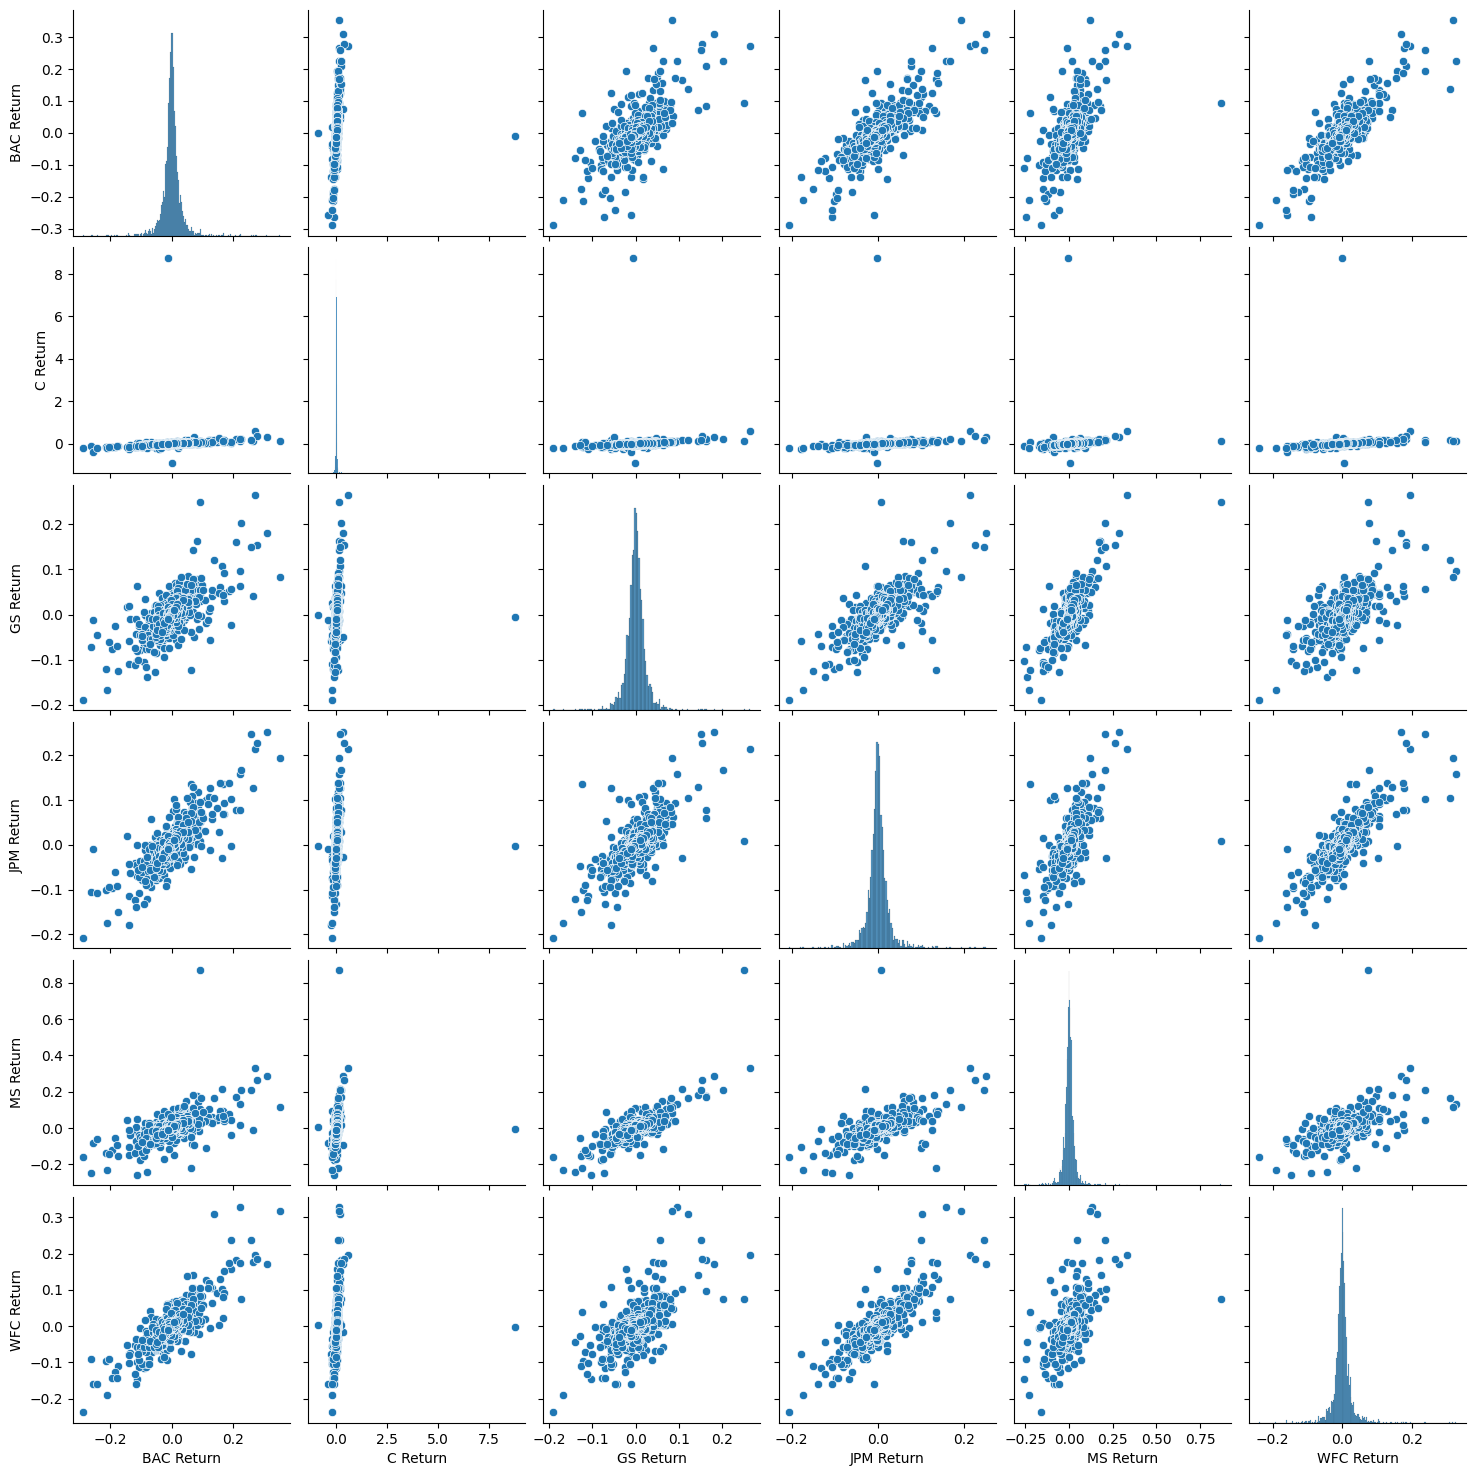

In [ ]:
sns.pairplot(returns[1:])

In [ ]:
returns.idxmin()

,0
BAC Return,2009-01-20
C Return,2011-05-06
GS Return,2009-01-20
JPM Return,2009-01-20
MS Return,2008-10-09
WFC Return,2009-01-20


In [ ]:
returns.idxmax()

,0
BAC Return,2009-04-09
C Return,2011-05-09
GS Return,2008-11-24
JPM Return,2009-01-21
MS Return,2008-10-13
WFC Return,2008-07-16


In [ ]:
returns.std()

,0
BAC Return,0.036650
C Return,0.179969
GS Return,0.025346
JPM Return,0.027656
MS Return,0.037820
WFC Return,0.030233


In [ ]:
returns.loc['2015-01-01':'2015-12-31'].std()

,0
BAC Return,0.016163
C Return,0.015289
GS Return,0.014046
JPM Return,0.014017
MS Return,0.016249
WFC Return,0.012591


/tmp/ipython-input-3595771006.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],color='green',bins=50)


<Axes: xlabel='MS Return', ylabel='Density'>

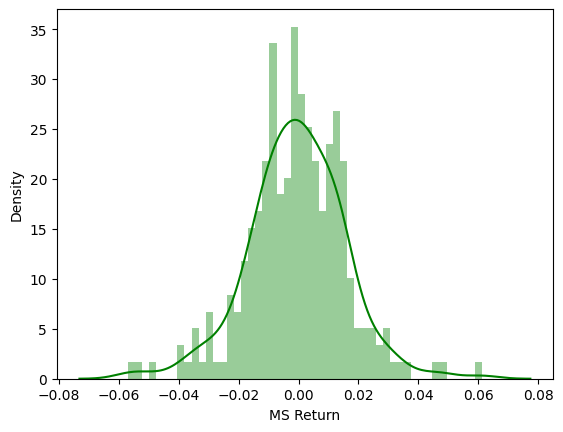

In [ ]:
sns.distplot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],color='green',bins=50)

/tmp/ipython-input-3154198916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=50)


<Axes: xlabel='C Return', ylabel='Density'>

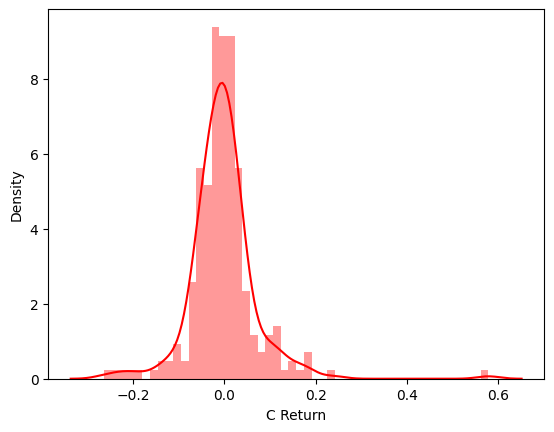

In [ ]:
sns.distplot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=50)

In [ ]:
import plotly
import cufflinks as cf
cf.go_offline()

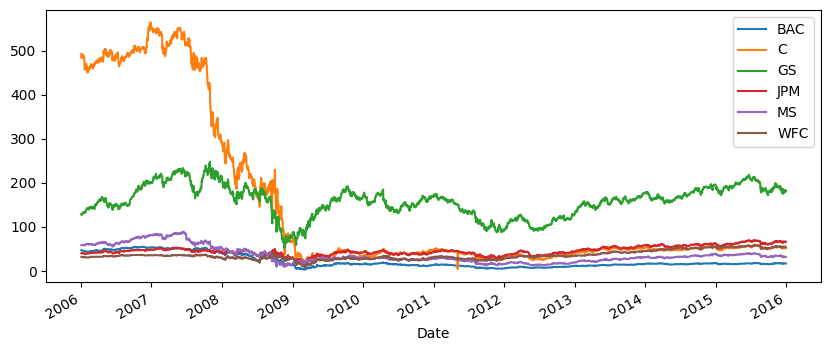

In [ ]:
for tick in tickers:
  bank_stocks[tick]['Close'].plot(label=tick,figsize=(10,4))
plt.legend()

<Axes: xlabel='Date'>

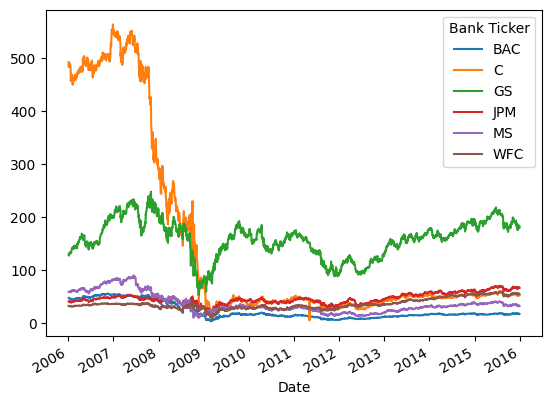

In [ ]:
bank_stocks.xs(key='Close',axis=1,level='Stock Info').plot()

In [ ]:
bank_stocks.xs(key='Close',axis=1,level='Stock Info').iplot()

/usr/local/lib/python3.12/dist-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of scatter.line
        Received value: 'rgba(255, 153, 51, np.float64(1.0))'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color:
            aliceblue, antiquewhite, aqua, aquamarine, azure,
            beige, bisque, black, blanchedalmond, blue,
            blueviolet, brown, burlywood, cadetblue,
            chartreuse, chocolate, coral, cornflowerblue,
            cornsilk, crimson, cyan, darkblue, darkcyan,
            darkgoldenrod, darkgray, darkgrey, darkgreen,
            darkkhaki, darkmagenta, darkolivegreen, darkorange,
            darkorchid, darkred, darksalmon, darkseagreen,
            darkslateblue, darkslategray, darkslategrey,
            darkturquoise, da

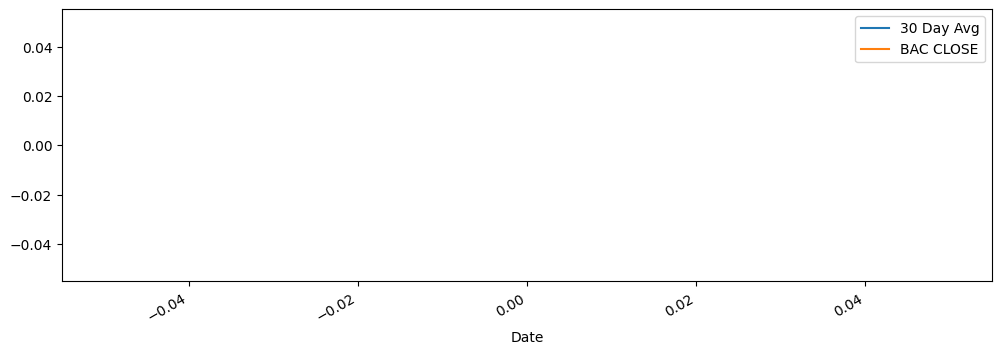

In [ ]:
plt.figure(figsize=(12,4))
BAC['Close'].loc['2008-01-01':'2008-01-01'].rolling(window=30).mean().plot(label='30 Day Avg')
BAC['Close'].loc['2008-01-01':'2008-01-01'].plot(label='BAC CLOSE')
plt.legend()

<Axes: xlabel='Bank Ticker', ylabel='Bank Ticker'>

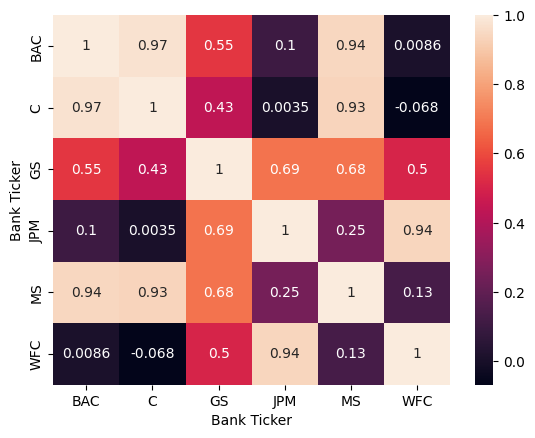

In [ ]:
sns.heatmap(bank_stocks.xs(key='Close',axis=1,level='Stock Info').corr(),annot=True)

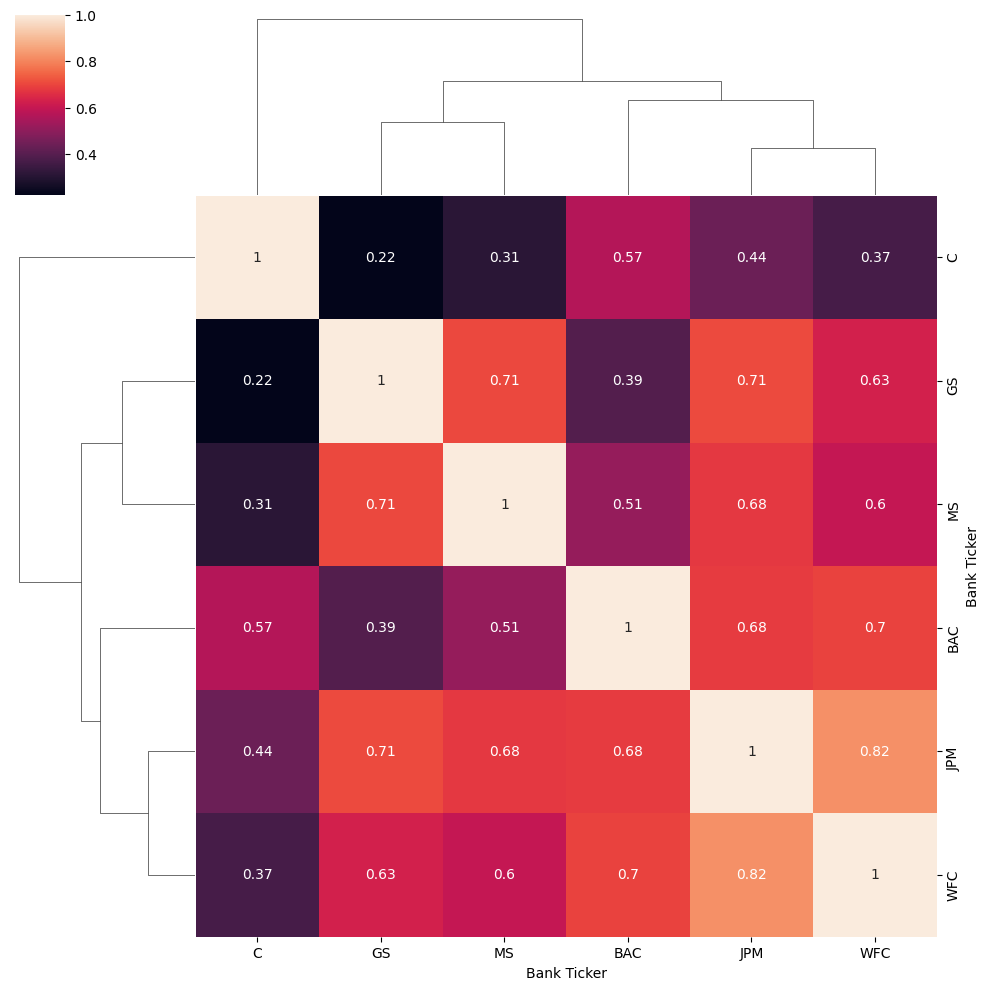

In [ ]:
sns.clustermap(bank_stocks.xs(key='Volume',axis=1,level='Stock Info').corr(),annot=True)

In [ ]:
close_corr=bank_stocks.xs(key='Close',axis=1,level='Stock Info').corr()
close_corr.iplot(kind='heatmap',colorscale='rdylbu')

In [ ]:
BAC[['Open','High','Low','Close']].loc['2015-01-01':'2015-12-31'].iplot(kind='candle')

In [ ]:
MS['Close'].loc['2015-01-01':'2017-01-01'].ta_plot(study='sma',periods=[13,21,55])

/usr/local/lib/python3.12/dist-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of scatter.line
        Received value: 'rgba(255, 153, 51, np.float64(1.0))'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color:
            aliceblue, antiquewhite, aqua, aquamarine, azure,
            beige, bisque, black, blanchedalmond, blue,
            blueviolet, brown, burlywood, cadetblue,
            chartreuse, chocolate, coral, cornflowerblue,
            cornsilk, crimson, cyan, darkblue, darkcyan,
            darkgoldenrod, darkgray, darkgrey, darkgreen,
            darkkhaki, darkmagenta, darkolivegreen, darkorange,
            darkorchid, darkred, darksalmon, darkseagreen,
            darkslateblue, darkslategray, darkslategrey,
            darkturquoise, da

In [ ]:
BAC['Close'].loc['2015-01-01':'2017-01-01'].ta_plot(study='boll')

/usr/local/lib/python3.12/dist-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of scatter.line
        Received value: 'rgba(255, 153, 51, np.float64(1.0))'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color:
            aliceblue, antiquewhite, aqua, aquamarine, azure,
            beige, bisque, black, blanchedalmond, blue,
            blueviolet, brown, burlywood, cadetblue,
            chartreuse, chocolate, coral, cornflowerblue,
            cornsilk, crimson, cyan, darkblue, darkcyan,
            darkgoldenrod, darkgray, darkgrey, darkgreen,
            darkkhaki, darkmagenta, darkolivegreen, darkorange,
            darkorchid, darkred, darksalmon, darkseagreen,
            darkslateblue, darkslategray, darkslategrey,
            darkturquoise, da